## Model 2: Hierarchical team model (Stan)

**Idea:** same covariates as Model 1, but team skill is modeled directly on the points scale with a hierarchical long-run team-strength component (`tau_team`) and a shared season-level effect (`tau_season`). One model input = **one team**; output = its **points** distribution.

**Backtest:** train through 2024/25 → predict **points** for each 2025/26 team.

**Forecast:** for a new season, use posterior `team_skill[team]`, draw a fresh shared season effect `tau_season * z`, and use covariates from the last training season. Promoted or unseen teams get `team_skill = 0` and `beta_promoted` via features.

$$\text{Pts}_{s,t} \sim t_{\nu}\big(\alpha + \text{team\_skill}_{t} + \text{season\_dev}_{s,t} + \gamma^\top x_{s,t},\; \sigma_{\mathrm{pts}}\big)$$

with $x$ = (`sot_diff_pg`, `pts_lag1`, `ppg_last10`, z-scored) plus `is_promoted`, and sum-to-zero constraints for identifiable team and season effects.
Student-$t$ with $\nu=5$ fixed; $\tau_{\mathrm{team}}$ controls persistent team-strength variation and $\tau_{\mathrm{season}}$ controls shared season-level shifts.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    compute_table,
    predict_team_points,
    build_predicted_table,
    compare_forecast_to_actual,
    forecast_season_summary,
    forecast_team_errors,
    plot_forecast_team_errors,
    print_forecast_season_summary,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [2]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
FEATURE_SEASON = "2425"  # last training season → covariates for 2526 forecast

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, season_to_idx, feature_stats = (
    prepare_table_stan_hierarchical(tables, TRAIN_SEASONS)
)
stan_data["nu"] = STUDENT_T_NU
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[FEATURE_SEASON]

print(f"Training rows (team-seasons): {stan_data['N']}")
print(f"Stan keys: {sorted(stan_data.keys())}")
print(f"Teams in training: {stan_data['T']}")
print(f"Test season {TEST_SEASON}: {len(test_teams)} teams")
print(tables.groupby("season")["Pts"].mean().tail(3))
print("\nFeature ranges (raw, training seasons):")
print(tables[["sot_diff_pg", "pts_lag1", "ppg_last10"]].describe().round(2))
print(f"\nForecast uses season {FEATURE_SEASON} (Stan index {last_season_idx})")

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Promoted / new teams (is_promoted=1, covariates=training mean):", new_in_test)


Training rows (team-seasons): 320
Stan keys: ['N', 'S', 'T', 'is_promoted', 'nu', 'ppg_last10', 'pts', 'pts_lag1', 'season', 'sot_diff_pg', 'team']
Teams in training: 42
Test season 2526: 20 teams
season
2223    52.65
2324    52.90
2425    52.35
Name: Pts, dtype: float64

Feature ranges (raw, training seasons):
       sot_diff_pg  pts_lag1  ppg_last10
count       320.00    320.00      320.00
mean          0.30     45.02        1.21
std           1.70     26.80        0.78
min          -3.76      0.00        0.00
25%          -0.74     38.00        0.70
50%           0.00     47.00        1.30
75%           1.14     63.25        1.80
max           6.03    100.00        3.00

Forecast uses season 2425 (Stan index 16)


### Prior selection (Model 2)

| Parameter | Prior | Expert rationale |
|-----------|-------|------------------|
| `intercept` | $\mathcal{N}(52, 15)$ | Baseline around the structural average points total in a 20-team league, with deliberately wide uncertainty. |
| `beta_sot`, `beta_form` | $\mathcal{N}(0, 10)$ | Broad process/form effects on z-scored inputs. |
| `beta_lag` | $\mathcal{N}(0, 1)$ | Allows previous-season points to help, but does not force a strong lag effect. |
| `beta_promoted` | $\mathcal{N}(-8, 8)$ | Weak prior belief that promoted teams may be below average, with substantial uncertainty. |
| `log_sigma_pts` | $\mathcal{N}(\log 8, 0.5)$ | Broad residual noise scale after team strength and covariates. |
| `log_tau_team` | $\mathcal{N}(\log 8, 0.5)$ | Broad persistent team-strength scale. |
| `log_tau_season` | $\mathcal{N}(\log 3, 0.5)$ | Broad shared season-level scale. |
| `team_skill_z`, `season_effect_z` | sum-to-zero standard Normal vectors | Non-centered geometry with interpretable points-scale multipliers. |

The hierarchy is:

$\text{skill_obs}_{n} = \text{team_skill}_{team[n]} + \text{season_effect}_{season[n]}$.

`team_skill` captures long-run residual quality. `season_effect` captures league-wide season shifts shared by all teams in a season. A previous version included one latent deviation for every team-season row, but that component was weakly identified because each team-season has only one point total and it competed with `sigma_pts`.


### Prior predictive checks

The checks below separate two questions required by the rubric:

- **Parameter priors:** do `sigma_pts`, `tau_team`, `tau_season`, `beta_promoted`, and the other coefficients imply football-scale values?
- **Measurement priors:** after combining parameters with lag-safe covariates, do simulated team-season point totals look broadly plausible before conditioning on observed points?


,0.05,0.50,0.95
intercept,27.232438,51.982183,76.509901
beta_sot,-16.878171,-0.112776,16.333961
beta_lag,-1.661283,-0.003802,1.661070
beta_form,-16.412126,0.144811,16.501374
beta_promoted,-21.291872,-8.055721,5.271295
sigma_pts,3.552955,7.963768,15.966901
tau_team,3.521057,7.950447,17.429204
tau_season,1.337478,2.978353,6.593077
team_skill_range,14.499330,34.036867,77.230746
season_effect_range,4.240698,10.263534,24.697056


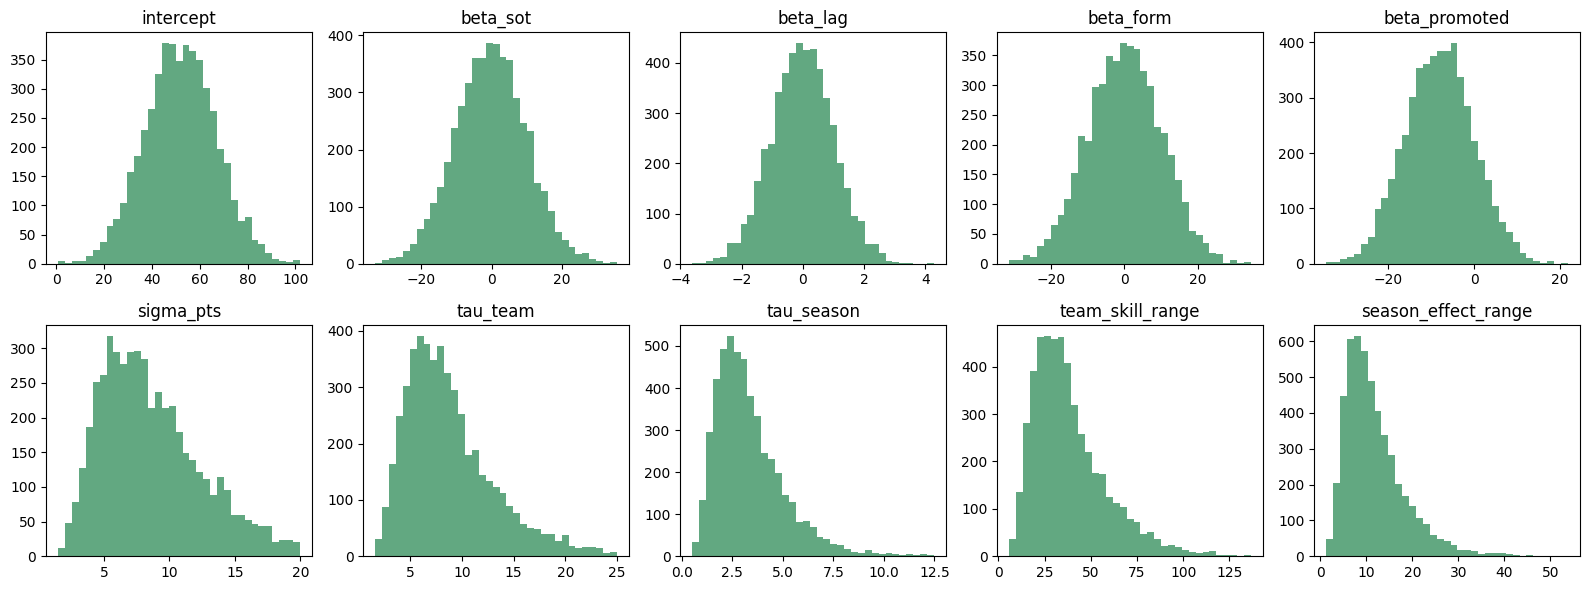

Prior points mean: 51.5; observed mean: 52.4
Prior central 90% interval: 9.4 to 93.3
Observed range: 12 to 100


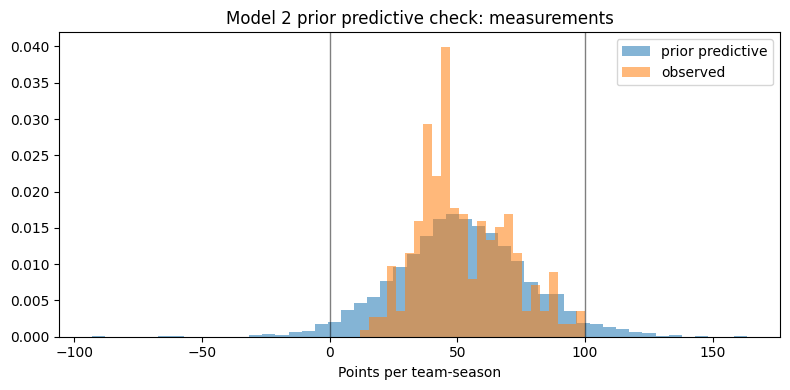

In [3]:
rng = np.random.default_rng(43)
n_prior = 5000
T = stan_data["T"]
S = stan_data["S"]
nu_prior = STUDENT_T_NU

def rtrunc_normal(mean, sd, lower=-np.inf, upper=np.inf, size=1):
    out = np.empty(size)
    filled = 0
    while filled < size:
        draws = rng.normal(mean, sd, size - filled)
        draws = draws[(draws >= lower) & (draws <= upper)]
        take = min(len(draws), size - filled)
        if take:
            out[filled:filled + take] = draws[:take]
            filled += take
    return out

intercept_p = rng.normal(52, 15, n_prior)
beta_sot_p = rng.normal(0, 10, n_prior)
beta_lag_p = rng.normal(0, 1, n_prior)
beta_form_p = rng.normal(0, 10, n_prior)
beta_promoted_p = rng.normal(-8, 8, n_prior)

sigma_p = np.exp(rtrunc_normal(np.log(8), 0.5, lower=np.log(0.5), upper=np.log(20), size=n_prior))
tau_team_p = np.exp(rtrunc_normal(np.log(8), 0.5, lower=np.log(1), upper=np.log(25), size=n_prior))
tau_season_p = np.exp(rtrunc_normal(np.log(3), 0.5, lower=np.log(0.25), upper=np.log(15), size=n_prior))
team_skill_z = rng.normal(0, 1, (n_prior, T))
team_skill_z -= team_skill_z.mean(axis=1, keepdims=True)
team_skill = tau_team_p[:, None] * team_skill_z
season_effect_z = rng.normal(0, 1, (n_prior, S))
season_effect_z -= season_effect_z.mean(axis=1, keepdims=True)
season_effect = tau_season_p[:, None] * season_effect_z

prior_params = pd.DataFrame({
    "intercept": intercept_p,
    "beta_sot": beta_sot_p,
    "beta_lag": beta_lag_p,
    "beta_form": beta_form_p,
    "beta_promoted": beta_promoted_p,
    "sigma_pts": sigma_p,
    "tau_team": tau_team_p,
    "tau_season": tau_season_p,
    "team_skill_range": team_skill.max(axis=1) - team_skill.min(axis=1),
    "season_effect_range": season_effect.max(axis=1) - season_effect.min(axis=1),
})
display(prior_params.quantile([0.05, 0.5, 0.95]).T)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), prior_params.columns):
    ax.hist(prior_params[col], bins=35, color="seagreen", alpha=0.75)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Measurement prior predictive: sample actual design rows, but draw parameters from prior.
idx = rng.integers(0, stan_data["N"], size=3000)
draw = rng.integers(0, n_prior, size=3000)
teams = np.asarray(stan_data["team"])[idx] - 1
seasons = np.asarray(stan_data["season"])[idx] - 1

skill_obs_prior = team_skill[draw, teams] + season_effect[draw, seasons]
mu_prior = (
    intercept_p[draw]
    + skill_obs_prior
    + beta_sot_p[draw] * np.asarray(stan_data["sot_diff_pg"])[idx]
    + beta_lag_p[draw] * np.asarray(stan_data["pts_lag1"])[idx]
    + beta_form_p[draw] * np.asarray(stan_data["ppg_last10"])[idx]
    + beta_promoted_p[draw] * np.asarray(stan_data["is_promoted"])[idx]
)
pts_prior = mu_prior + sigma_p[draw] * rng.standard_t(nu_prior, size=len(draw))

print(f"Prior points mean: {pts_prior.mean():.1f}; observed mean: {np.mean(stan_data['pts']):.1f}")
print(f"Prior central 90% interval: {np.quantile(pts_prior, 0.05):.1f} to {np.quantile(pts_prior, 0.95):.1f}")
print(f"Observed range: {np.min(stan_data['pts']):.0f} to {np.max(stan_data['pts']):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(pts_prior, bins=50, density=True, alpha=0.55, label="prior predictive")
plt.hist(stan_data["pts"], bins=25, density=True, alpha=0.55, label="observed")
plt.axvline(0, color="black", lw=1, alpha=0.5)
plt.axvline(100, color="black", lw=1, alpha=0.5)
plt.xlabel("Points per team-season")
plt.title("Model 2 prior predictive check: measurements")
plt.legend()
plt.tight_layout()
plt.show()


**Prior predictive interpretation (Model 2):** `tau_team` controls persistent club quality on the points scale, `tau_season` controls shared season-level shifts, and `sigma_pts` carries residual team-specific surprises after covariates and team strength. The measurement prior can be wider than observed data, but its central mass should describe plausible league seasons rather than impossible point totals.

In [4]:
model = CmdStanModel(stan_file="stan/team_hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


11:58:24 - cmdstanpy - INFO - compiling stan file /workspace/DA_Project/stan/team_hierarchical.stan to exe file /workspace/DA_Project/stan/team_hierarchical
11:58:31 - cmdstanpy - INFO - compiled model executable: /workspace/DA_Project/stan/team_hierarchical
11:58:31 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

11:58:36 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check divergences (`fit.diagnose()` above), $\hat{R}$, and ESS.
Target: $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$ per parameter.


                     Mean      MCSE    StdDev       MAD          5%  \
intercept       50.214700  0.024699  1.107080  1.108390   48.441700   
beta_sot         6.292220  0.019318  1.052310  1.064830    4.571020   
beta_lag         0.079572  0.011099  0.872373  0.880510   -1.342730   
beta_form        1.310320  0.015597  1.153380  1.163970   -0.592534   
beta_promoted   -8.399780  0.040845  2.626550  2.548860  -12.733300   
sigma_pts        8.726070  0.006640  0.469190  0.463876    7.989540   
tau_team         7.467070  0.037470  1.382030  1.363140    5.343220   
tau_season       1.391500  0.006625  0.484920  0.467560    0.735998   
lp__          -925.868000  0.247355  8.370840  8.465650 -940.236000   

                      50%        95%  ESS_bulk  ESS_tail    R_hat  
intercept       50.199200   52.04810   2012.34   2820.29  1.00113  
beta_sot         6.293450    7.99644   3007.06   3868.76  1.00023  
beta_lag         0.077922    1.53020   6214.19   4026.44  1.00042  
beta_form        

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
intercept,50.215,1.107,48.217,52.384,2012.0,2820.0,1.0
beta_sot,6.292,1.052,4.435,8.320,3007.0,3869.0,1.0
beta_lag,0.080,0.872,-1.500,1.794,6214.0,4026.0,1.0
beta_form,1.310,1.153,-0.814,3.418,5502.0,4678.0,1.0
beta_promoted,-8.400,2.627,-13.465,-3.446,4174.0,4369.0,1.0
sigma_pts,8.726,0.469,7.878,9.633,5155.0,3444.0,1.0
tau_team,7.467,1.382,4.980,10.113,1365.0,2882.0,1.0
tau_season,1.392,0.485,0.610,2.299,5373.0,4102.0,1.0


Parameters with R-hat > 1.01: 0
Parameters with ESS_bulk < 400: 0


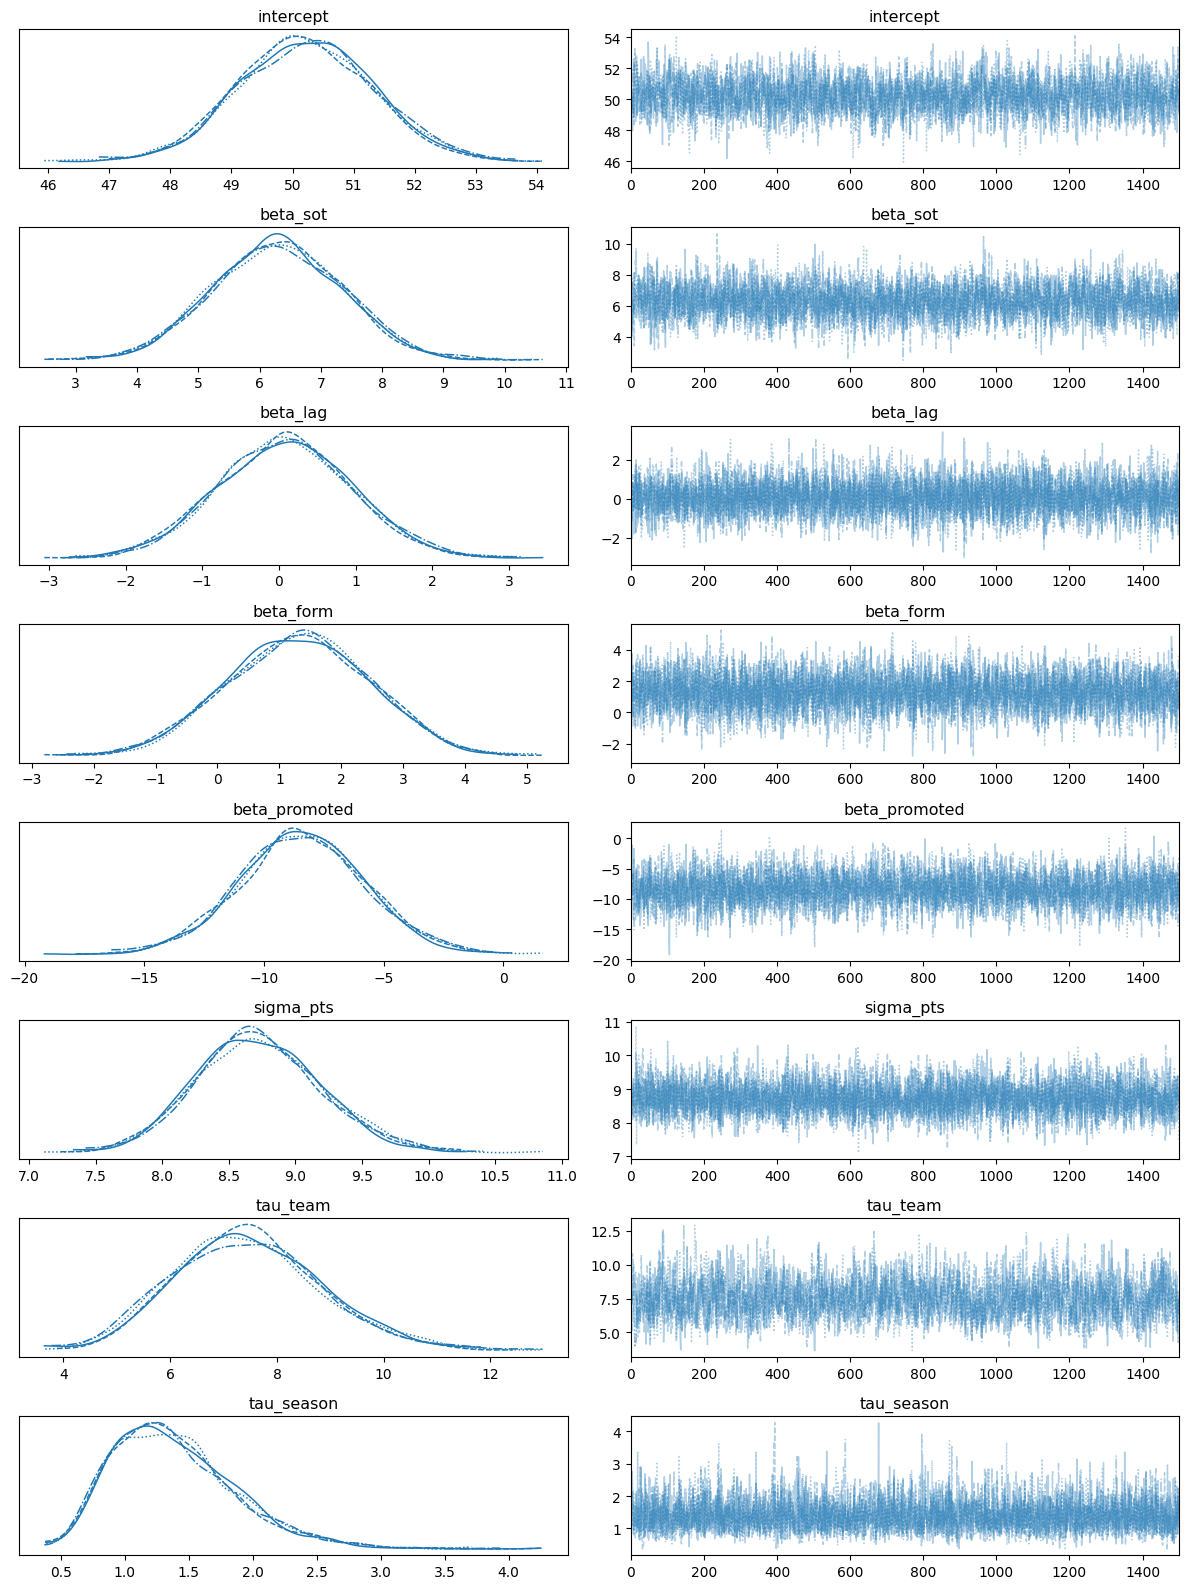

In [5]:
param_vars = [
    "intercept", "beta_sot", "beta_lag", "beta_form", "beta_promoted",
    "sigma_pts", "tau_team", "tau_season",
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
display(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    display(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    display(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


### Interpreting $\sigma_{\mathrm{pts}}$, $\tau_{\mathrm{team}}$, $\tau_{\mathrm{season}}$, and skills

| Parameter | Order of magnitude | Meaning |
|-----------|-------------------|---------|
| `tau_team` | several to low-double-digit pts | Persistent residual team quality beyond process metrics. |
| `tau_season` | several pts | Shared season-level shift across all teams in a historical season. |
| `team_skill[t]` | learned points-scale range across clubs | Long-run residual club strength on the points scale. |
| `skill[s,t]` | `team_skill + season_effect` | Combined historical skill for season-team rows. |
| `sigma_pts` | learned residual scale | Student-$t$ scale for leftover noise; approximate SD is $\sigma\sqrt{\nu/(\nu-2)}$. |

**Interpretation:** `sigma_pts` is not the raw spread of table points. It is the leftover noise after team quality, season-level shifts, promoted status, and lag-safe covariates. The previous team-season deviation component was removed because it was weakly identified and competed with this residual scale.


In [6]:
skill_mean = fit.stan_variable("team_skill").mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

skill_table = pd.DataFrame({
    "team": [idx_to_team[j+1] for j in range(len(skill_mean))],
    "team_skill": skill_mean,
}).sort_values("team_skill", ascending=False)
skill_table.head(10)


,team,team_skill
22,Man City,17.919540
23,Man United,13.427350
0,Arsenal,12.709926
20,Liverpool,10.962293
11,Chelsea,10.568870
36,Tottenham,10.268597
7,Brentford,4.020406
33,Stoke,2.915631
1,Aston Villa,2.315304
25,Newcastle,1.999359


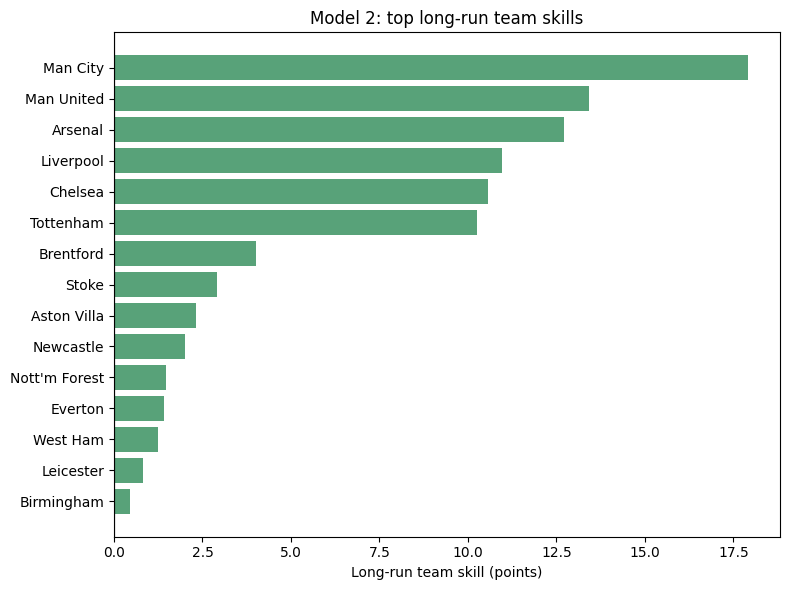

In [7]:
plot_data = skill_table.head(15).sort_values("team_skill")
plt.figure(figsize=(8, 6))
plt.barh(plot_data["team"], plot_data["team_skill"], color="seagreen", alpha=0.8)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Long-run team skill (points)")
plt.title("Model 2: top long-run team skills")
plt.tight_layout()
plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


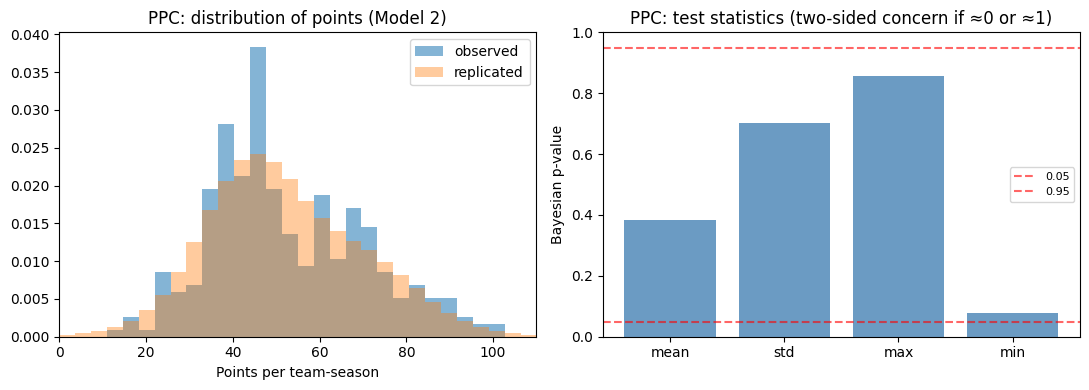

PPC x-axis shown: 0.0 to 110.0 points
Replicated draws outside shown range: 0.39%
  mean: p = 0.385
  std: p = 0.703
  max: p = 0.857
  min: p = 0.079


In [8]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="hierarchical")
y_rep_flat = y_rep.reshape(-1)

# Fixed PPC scale so observed histograms are directly comparable across models.
plot_low, plot_high = 0, 110
bins = np.linspace(plot_low, plot_high, 31)
outside = np.mean((y_rep_flat < plot_low) | (y_rep_flat > plot_high))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=bins, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep_flat, bins=bins, density=True, alpha=0.4, label="replicated")
axes[0].set_xlim(plot_low, plot_high)
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points (Model 2)")
axes[0].legend()

stats = {"mean": np.mean, "std": np.std, "max": np.max, "min": np.min}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6, label="0.05")
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6, label="0.95")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics (two-sided concern if ≈0 or ≈1)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"PPC x-axis shown: {plot_low:.1f} to {plot_high:.1f} points")
print(f"Replicated draws outside shown range: {100 * outside:.2f}%")
for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 2):** same logic as Model 1. If replicated points are too narrow or too wide relative to observed points, the likely culprits are `sigma_pts`, `tau_team`, or `tau_season`. If promoted teams are systematically overpredicted, inspect `beta_promoted`. Good PPC behavior means the hierarchical team-strength plus season-effect model still reproduces the empirical distribution of table points, not only the parameter diagnostics.

### Backtest 2025/26 — per-team points

For each test team we call `predict_team_points` and compare predicted vs actual **points**. Position comparison uses ranking as a derived summary; assembling a full table from 20 predictions is shown in `05_backtest_models_comparison`.

**Forecast skill (Model 2):** posterior `team_skill[team]` plus a fresh shared season-level draw `tau_season * z` for season 2526. Covariates come from 2425 via `build_forecast_features`, and remaining team-specific uncertainty is represented by the Student-$t$ predictive residual.


In [9]:
forecast_features = build_forecast_features(
    matches, FEATURE_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

# Per-team posterior predictive points
single_rows = []
for j, team in enumerate(test_teams):
    pred = predict_team_points(
        fit,
        team,
        team_to_idx,
        model="hierarchical",
        team_features=forecast_features[team],
        n_sims=500,
        seed=42 + j,
    )
    single_rows.append(pred)
single_df = pd.DataFrame(single_rows)
display(single_df[["team", "pts_median", "pts_mean", "pts_q05", "pts_q95"]].sort_values("pts_median", ascending=False))

pred_table = build_predicted_table(
    fit,
    test_teams,
    team_to_idx,
    model="hierarchical",
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

comparison = compare_forecast_to_actual(pred_table, matches, TEST_SEASON)
season_summary = forecast_season_summary(comparison)
team_errors = forecast_team_errors(comparison)

print_forecast_season_summary(season_summary, season=TEST_SEASON)

display(team_errors)
season_summary


,team,pts_median,pts_mean,pts_q05,pts_q95
12,Man City,76.667807,77.206985,58.875844,94.228954
0,Arsenal,69.738739,68.409262,47.887855,85.812608
11,Liverpool,69.399340,69.722835,51.833137,87.519836
6,Chelsea,67.484401,67.614321,48.614662,85.178978
13,Man United,64.012771,63.894598,43.829916,81.829020
17,Tottenham,57.448184,57.575633,41.274186,74.377593
1,Aston Villa,55.213415,55.326749,35.625952,73.758624
4,Brighton,53.890054,53.769522,36.686330,72.411962
14,Newcastle,53.655242,53.997893,35.168766,72.147365
7,Crystal Palace,52.014241,52.324578,35.141296,68.728277


Season 2526 — Point forecast quality
  Sum |point error| over all teams:  180 pts
  Mean |point error| per team:        9.01 pts  (180 / 20)
  Mean signed point error (bias):     +1.56 pts
  Mean predicted / actual points:     53.4 / 51.8
  Sum |position error|:               72 places
  Mean |position error| per team:     3.60 places  (72 / 20)


,team,pts_median,pts_actual,pts_error,pts_abs_error,pos_median,pos_actual,pos_error,pos_abs_error
15,Wolves,47.044167,20,27.044167,27.044167,16,20,-4,4
18,Sunderland,34.958827,54,-19.041173,19.041173,19,7,12,12
5,Tottenham,57.448184,41,16.448184,16.448184,6,17,-11,11
3,Chelsea,67.484401,52,15.484401,15.484401,4,10,-6,6
1,Arsenal,69.738739,85,-15.261261,15.261261,2,1,1,1
19,Burnley,34.069375,22,12.069375,12.069375,20,19,1,1
17,Leeds,35.839164,47,-11.160836,11.160836,18,14,4,4
6,Aston Villa,55.213415,65,-9.786585,9.786585,7,4,3,3
2,Liverpool,69.399340,60,9.399340,9.399340,3,5,-2,2
16,West Ham,46.220831,39,7.220831,7.220831,17,18,-1,1


n_teams               20.000000
pts_pred_mean         53.362861
pts_actual_mean       51.800000
pts_mae                9.011489
pts_abs_error_sum    180.229776
pts_bias               1.562861
pos_mae                3.600000
pos_abs_error_sum     72.000000
pos_bias               0.000000
dtype: float64

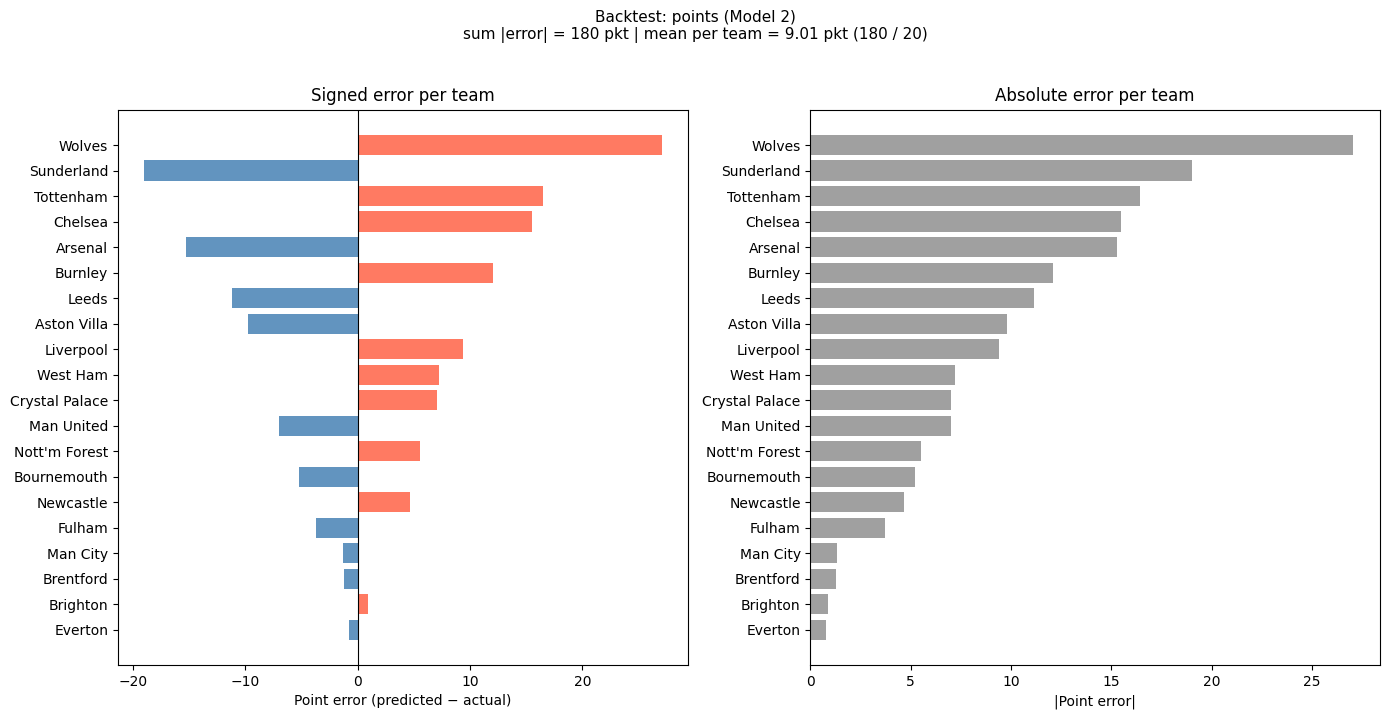

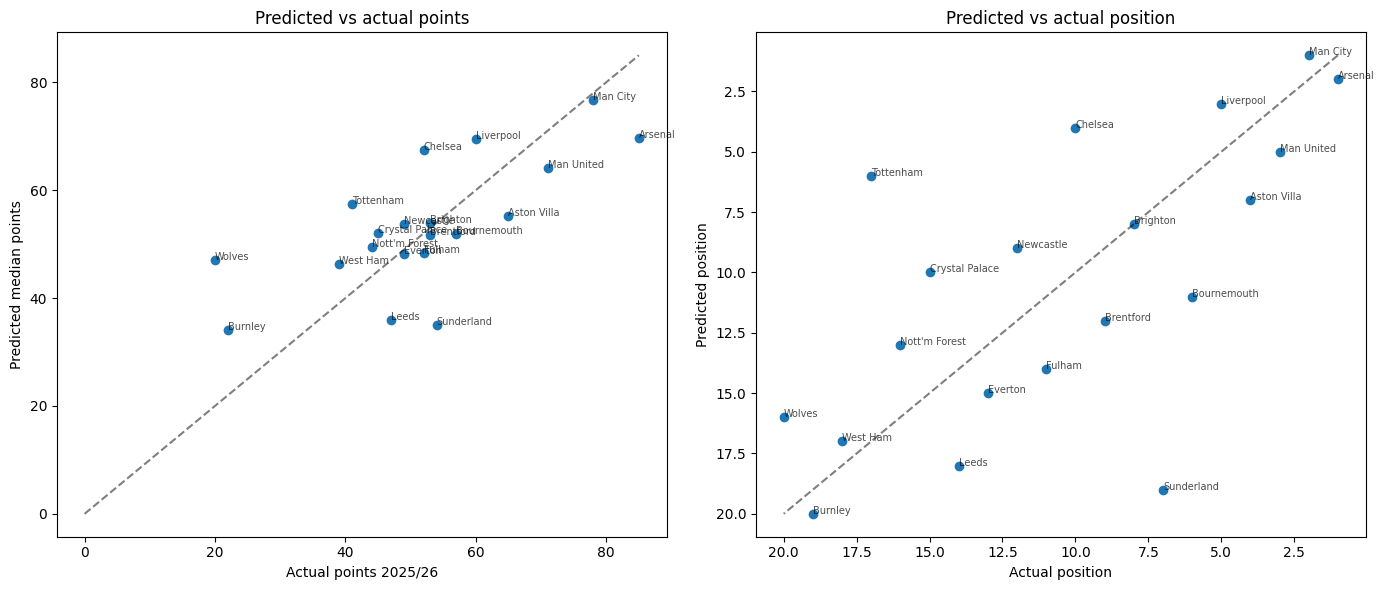

In [10]:
plot_forecast_team_errors(comparison, season=TEST_SEASON, title="Backtest: points (Model 2)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(comparison["pts_actual"], comparison["pts_median"])
for _, r in comparison.iterrows():
    axes[0].annotate(r["team"], (r["pts_actual"], r["pts_median"]), fontsize=7, alpha=0.7)
mx = max(comparison["pts_actual"].max(), comparison["pts_median"].max())
axes[0].plot([0, mx], [0, mx], "k--", alpha=0.5)
axes[0].set_xlabel("Actual points 2025/26")
axes[0].set_ylabel("Predicted median points")
axes[0].set_title("Predicted vs actual points")

axes[1].scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    axes[1].annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
axes[1].plot([1, 20], [1, 20], "k--", alpha=0.5)
axes[1].set_xlabel("Actual position")
axes[1].set_ylabel("Predicted position")
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_title("Predicted vs actual position")
plt.tight_layout()
plt.show()


### WAIC / LOO

This is a single-model diagnostic version of the information criteria. The final comparison between Model 1 and Model 2 is done in `04_forecast_2627_comparison` on the same team-season rows.

For PSIS-LOO, check `pareto_k`: values $\leq 0.7$ are reliable; values above 0.7 indicate influential team-seasons. For WAIC, warnings about high posterior variance of log predictive density mean WAIC may be less stable, so PSIS-LOO and the backtest (`05_backtest_models_comparison`, `04_forecast_2627_comparison`) should receive more weight.

In [11]:
idata = az.from_cmdstanpy(fit)
print(az.waic(idata))
loo = az.loo(idata, pointwise=True)
print(loo)

k = loo.pareto_k.values
n_good = int((k <= 0.7).sum())
n_bad = int(((k > 0.7) & (k <= 1)).sum())
n_very_bad = int((k > 1).sum())
print(f"\nPareto k: good (≤0.7) {n_good}/{len(k)} ({100 * n_good / len(k):.1f}%)")
print(f"           bad (0.7–1] {n_bad}, very bad (>1) {n_very_bad}")


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1228.75    13.71
p_waic       41.04        -

There has been a warning during the calculation. Please check the results.
Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1228.99    13.69
p_loo       41.28        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      320  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Pareto k: good (≤0.7) 320/320 (100.0%)
           bad (0.7–1] 0, very bad (>1) 0
